## Generate Dataset

In [1]:
##create samples
import numpy as np
import pandas as pd

np.random.seed(42)

N_ROBOTS = 30
N_DAYS = 14
INTERVAL_MINUTES = 5

samples_per_day = 24 * 60 // INTERVAL_MINUTES
samples_per_robot = samples_per_day * N_DAYS

print("Samples per robot:", samples_per_robot)
print("Total samples:", samples_per_robot * N_ROBOTS)

Samples per robot: 4032
Total samples: 120960


In [2]:
## modes
MODES = ["PATROL", "ALERT", "CHARGING", "FAULT"]

mode_probabilities = {
    "PATROL": 0.65,
    "ALERT": 0.15,
    "CHARGING": 0.15,
    "FAULT": 0.05
}

In [3]:
## make the model to sustain for certain period
def generate_mode_sequence(n_samples):
    modes = []

    while len(modes) < n_samples:
        mode = np.random.choice(
            MODES,
            p=[
                mode_probabilities["PATROL"],
                mode_probabilities["ALERT"],
                mode_probabilities["CHARGING"],
                mode_probabilities["FAULT"]
            ]
        )

        if mode == "PATROL":
            duration = np.random.randint(12, 48)   # 1–4 hours

        elif mode == "ALERT":
            duration = np.random.randint(3, 12)    # 15–60 min

        elif mode == "CHARGING":
            duration = np.random.randint(12, 36)   # 1–3 hours

        else:  # FAULT
            duration = np.random.randint(3, 18)    # 15–90 min

        modes.extend([mode] * duration)

    return modes[:n_samples]

In [4]:
## modor generate sensor values
def generate_sensor_values(mode, t, battery_soc):
    
    if mode == "PATROL":
        accel_x = 0.4 * np.sin(2 * np.pi * t / 12) + np.random.normal(0, 0.15)
        accel_y = 0.3 * np.sin(2 * np.pi * t / 10) + np.random.normal(0, 0.15)
        accel_z = 9.81 + np.random.normal(0, 0.12)

        motor_current = (
            2.0
            + 0.4 * np.sin(2 * np.pi * t / 15)
            + np.random.normal(0, 0.15)
        )

        proximity = np.clip(
            3.0 + np.random.normal(0, 1.0),
            0.2,
            8.0
        )

        rssi = np.random.normal(-58, 5)

        battery_soc -= np.random.uniform(0.01, 0.04)

        task_success = np.random.choice(
            [1, 0],
            p=[0.95, 0.05]
        )
        
    elif mode == "ALERT":
        accel_x = (
                0.9 * np.sin(2 * np.pi * t / 7)+ np.random.normal(0, 0.3)
            )

        accel_y = (
            0.7 * np.sin(2 * np.pi * t / 6)
            + np.random.normal(0, 0.3)
        )

        accel_z = 9.81 + np.random.normal(0, 0.3)

        motor_current = (
            3.3
            + 0.8 * np.sin(2 * np.pi * t / 8)
            + np.random.normal(0, 0.3)
        )

        proximity = np.clip(
            1.5 + np.random.normal(0, 0.7),
            0.1,
            6.0
        )

        rssi = np.random.normal(-60, 6)

        battery_soc -= np.random.uniform(0.03, 0.07)

        task_success = np.random.choice(
            [1, 0],
            p=[0.9, 0.1]
        )
        
    elif mode == "CHARGING":

        accel_x = np.random.normal(0, 0.03)
        accel_y = np.random.normal(0, 0.03)
        accel_z = 9.81 + np.random.normal(0, 0.03)

        motor_current = np.random.normal(0.2, 0.05)

        proximity = np.clip(
            np.random.normal(0.4, 0.1),
            0.1,
            1.0
        )

        rssi = np.random.normal(-45, 3)

        battery_soc += np.random.uniform(0.08, 0.2)

        task_success = 1
        
    elif mode == "FAULT":

        accel_x = np.random.normal(0, 0.8)
        accel_y = np.random.normal(0, 0.8)
        accel_z = 9.81 + np.random.normal(0, 0.7)

        motor_current = (
            4.5
            + 1.2 * np.sin(2 * np.pi * t / 3)
            + np.random.normal(0, 0.7)
        )

        proximity = np.clip(
            np.random.normal(2.0, 1.5),
            0.1,
            8.0
        )

        rssi = np.random.normal(-72, 8)

        battery_soc -= np.random.uniform(0.05, 0.12)

        task_success = np.random.choice(
            [1, 0],
            p=[0.3, 0.7]
        )
        
    battery_soc = np.clip(battery_soc, 0, 100)

    return (
        accel_x,
        accel_y,
        accel_z,
        motor_current,
        proximity,
        rssi,
        battery_soc,
        task_success
    )

In [5]:
rows = []

start_time = pd.Timestamp("2026-08-10 00:00:00")

for robot_num in range(1, N_ROBOTS + 1):

    robot_id = f"R{robot_num:02d}"

    timestamps = pd.date_range(
        start=start_time,
        periods=samples_per_robot,
        freq="5min"
    )

    modes = generate_mode_sequence(samples_per_robot)

    battery_soc = np.random.uniform(60, 100)

    for t, (timestamp, mode) in enumerate(zip(timestamps, modes)):

        (
            accel_x,
            accel_y,
            accel_z,
            motor_current,
            proximity,
            rssi,
            battery_soc,
            task_success
        ) = generate_sensor_values(
            mode,
            t,
            battery_soc
        )

        rows.append({
            "timestamp": timestamp,
            "robot_id": robot_id,
            "mode": mode,
            "accel_x": accel_x,
            "accel_y": accel_y,
            "accel_z": accel_z,
            "motor_current": motor_current,
            "proximity": proximity,
            "rssi": rssi,
            "battery_soc": battery_soc,
            "task_success": task_success
        })

In [6]:
df = pd.DataFrame(rows)

df.head()

,timestamp,robot_id,mode,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
0,2026-08-10 00:00:00,R01,PATROL,0.181560,-0.022685,9.765057,1.806318,2.234491,-55.888431,93.100778,0
1,2026-08-10 00:05:00,R01,PATROL,0.003813,-0.122254,9.707094,2.288695,4.781291,-61.387078,93.089032,1
2,2026-08-10 00:10:00,R01,PATROL,0.114086,0.233848,9.832063,2.383943,5.134641,-56.865756,93.065962,1
3,2026-08-10 00:15:00,R01,PATROL,0.412985,0.196385,9.728399,2.340912,2.719345,-61.019880,93.026576,1
4,2026-08-10 00:20:00,R01,PATROL,0.264022,0.340855,10.063573,2.323048,2.675605,-55.376955,93.016117,1


### Sanity check

In [7]:
df.shape

(120960, 11)

In [8]:
df["mode"].value_counts()

mode
PATROL      96458
CHARGING    17102
ALERT        5244
FAULT        2156
Name: count, dtype: int64

In [9]:
df["mode"].value_counts(normalize=True)

mode
PATROL      0.797437
CHARGING    0.141386
ALERT       0.043353
FAULT       0.017824
Name: proportion, dtype: float64

In [10]:
# Check missing values
df.isnull().sum()

timestamp        0
robot_id         0
mode             0
accel_x          0
accel_y          0
accel_z          0
motor_current    0
proximity        0
rssi             0
battery_soc      0
task_success     0
dtype: int64

In [11]:
# Basic statistics
df.describe()

,timestamp,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
count,120960,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000,120960.000000
mean,2026-08-16 23:57:29.999999,0.000155,-0.001067,9.810299,1.847455,2.549354,-56.496667,70.264335,0.943312
min,2026-08-10 00:00:00,-2.513802,-2.482482,7.650570,-0.001142,0.100000,-95.513880,23.399879,0.000000
25%,2026-08-13 11:58:45,-0.231157,-0.174428,9.739428,1.621960,1.676326,-61.086181,57.903070,1.000000
50%,2026-08-16 23:57:30,0.000140,0.000214,9.809817,1.944115,2.695850,-57.121369,71.020018,1.000000
75%,2026-08-20 11:56:15,0.230678,0.173720,9.880330,2.273319,3.489544,-52.389033,83.487646,1.000000
max,2026-08-23 23:55:00,2.647071,2.687603,12.120806,7.449074,7.293276,-34.044172,100.000000,1.000000
std,NaN,0.338154,0.282058,0.155505,0.861987,1.309361,7.021399,16.646870,0.231247


In [12]:
df.groupby("mode")[
    ["accel_x", "accel_y", "accel_z",
     "motor_current", "proximity",
     "rssi", "battery_soc", "task_success"]
].mean().round(3)

,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success
mode,,,,,,,,
ALERT,0.000,-0.009,9.808,3.306,1.515,-59.939,69.794,0.902
CHARGING,0.000,0.000,9.810,0.200,0.399,-45.008,72.319,1.000
FAULT,0.002,-0.028,9.831,4.502,2.089,-71.900,69.552,0.289
PATROL,0.000,-0.000,9.810,2.001,2.997,-58.002,69.941,0.950


In [13]:
df["imu_magnitude"] = np.sqrt(
    df["accel_x"]**2 +
    df["accel_y"]**2 +
    df["accel_z"]**2
)

## PSD Analysis Using High-Frequency Synthetic Sensor Windows

The 5-minute fleet telemetry is retained for fleet-level operational analysis.
For spectral analysis, a separate high-frequency synthetic sensor stream is
generated at 20 Hz so that the specified 0–5 Hz frequency range is observable.

At a sampling frequency of 20 Hz, the Nyquist frequency is 10 Hz, allowing
the required frequency bands to be analyzed:

- Low: 0–0.5 Hz
- Medium: 0.5–2 Hz
- High: 2–5 Hz

In [46]:
# High-frequency sensor stream parameters

HF_FS = 20
WINDOW_SECONDS = 30
HF_SAMPLES = HF_FS * WINDOW_SECONDS
N_WINDOWS_PER_MODE = 20

print("Samples per window:", HF_SAMPLES)
print("Sampling frequency:", HF_FS, "Hz")
print("Nyquist frequency:", HF_FS / 2, "Hz")

Samples per window: 600
Sampling frequency: 20 Hz
Nyquist frequency: 10.0 Hz


In [47]:
def generate_hf_sensor_window(mode, fs=20, duration=30):
    """
    Generate one high-frequency synthetic sensor window
    for a given operational mode.
    """

    n = fs * duration
    t = np.arange(n) / fs

    if mode == "PATROL":
        # Mostly low-frequency periodic movement
        motor_current = (
            2.0
            + 0.35 * np.sin(2 * np.pi * 0.3 * t)
            + 0.10 * np.sin(2 * np.pi * 1.0 * t)
            + np.random.normal(0, 0.10, n)
        )

        accel_x = (
            0.25 * np.sin(2 * np.pi * 0.4 * t)
            + np.random.normal(0, 0.08, n)
        )

        accel_y = (
            0.20 * np.sin(2 * np.pi * 0.5 * t)
            + np.random.normal(0, 0.08, n)
        )

        accel_z = (
            9.81
            + 0.15 * np.sin(2 * np.pi * 0.4 * t)
            + np.random.normal(0, 0.06, n)
        )

    elif mode == "ALERT":
        # Stronger low- and medium-frequency activity
        motor_current = (
            3.2
            + 0.30 * np.sin(2 * np.pi * 0.4 * t)
            + 0.45 * np.sin(2 * np.pi * 1.5 * t)
            + np.random.normal(0, 0.15, n)
        )

        accel_x = (
            0.30 * np.sin(2 * np.pi * 0.6 * t)
            + 0.30 * np.sin(2 * np.pi * 1.7 * t)
            + np.random.normal(0, 0.12, n)
        )

        accel_y = (
            0.25 * np.sin(2 * np.pi * 0.7 * t)
            + 0.25 * np.sin(2 * np.pi * 1.8 * t)
            + np.random.normal(0, 0.12, n)
        )

        accel_z = (
            9.81
            + 0.25 * np.sin(2 * np.pi * 1.5 * t)
            + np.random.normal(0, 0.10, n)
        )

    elif mode == "CHARGING":
        # Minimal motor activity and vibration
        motor_current = (
            0.2
            + 0.03 * np.sin(2 * np.pi * 0.1 * t)
            + np.random.normal(0, 0.03, n)
        )

        accel_x = np.random.normal(0, 0.02, n)
        accel_y = np.random.normal(0, 0.02, n)
        accel_z = 9.81 + np.random.normal(0, 0.02, n)

    else:  # FAULT
        # Strong higher-frequency components and irregularity
        motor_current = (
            4.5
            + 0.25 * np.sin(2 * np.pi * 0.4 * t)
            + 0.50 * np.sin(2 * np.pi * 1.5 * t)
            + 0.90 * np.sin(2 * np.pi * 3.5 * t)
            + np.random.normal(0, 0.30, n)
        )

        accel_x = (
            0.20 * np.sin(2 * np.pi * 0.5 * t)
            + 0.70 * np.sin(2 * np.pi * 3.2 * t)
            + np.random.normal(0, 0.25, n)
        )

        accel_y = (
            0.20 * np.sin(2 * np.pi * 0.6 * t)
            + 0.60 * np.sin(2 * np.pi * 3.8 * t)
            + np.random.normal(0, 0.25, n)
        )

        accel_z = (
            9.81
            + 0.60 * np.sin(2 * np.pi * 3.5 * t)
            + np.random.normal(0, 0.20, n)
        )

    imu_magnitude = np.sqrt(
        accel_x**2 +
        accel_y**2 +
        accel_z**2
    )

    return pd.DataFrame({
        "time": t,
        "mode": mode,
        "motor_current": motor_current,
        "accel_x": accel_x,
        "accel_y": accel_y,
        "accel_z": accel_z,
        "imu_magnitude": imu_magnitude
    })

In [48]:
np.random.seed(42)

hf_windows = []

for mode in MODES:
    for window_id in range(N_WINDOWS_PER_MODE):

        window = generate_hf_sensor_window(
            mode=mode,
            fs=HF_FS,
            duration=WINDOW_SECONDS
        )

        window["window_id"] = window_id

        hf_windows.append(window)

hf_df = pd.concat(
    hf_windows,
    ignore_index=True
)

hf_df.head()

,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0


In [49]:
hf_df.shape

(48000, 8)

In [50]:
hf_df.groupby("mode").size()

mode
ALERT       12000
CHARGING    12000
FAULT       12000
PATROL      12000
dtype: int64

### Welch PSD

In [51]:
from scipy.signal import welch

In [52]:
def average_window_psd(
    hf_df,
    mode,
    signal_col,
    fs=20,
    nperseg=256
):
    """
    Compute Welch PSD for each window separately,
    then average PSD across windows for one operational mode.
    """

    mode_df = hf_df[hf_df["mode"] == mode]

    psds = []

    for window_id, window_df in mode_df.groupby("window_id"):

        signal = window_df[signal_col].values

        freqs, psd = welch(
            signal,
            fs=fs,
            nperseg=nperseg
        )

        psds.append(psd)

    psds = np.array(psds)

    mean_psd = psds.mean(axis=0)
    std_psd = psds.std(axis=0)

    return freqs, mean_psd, std_psd

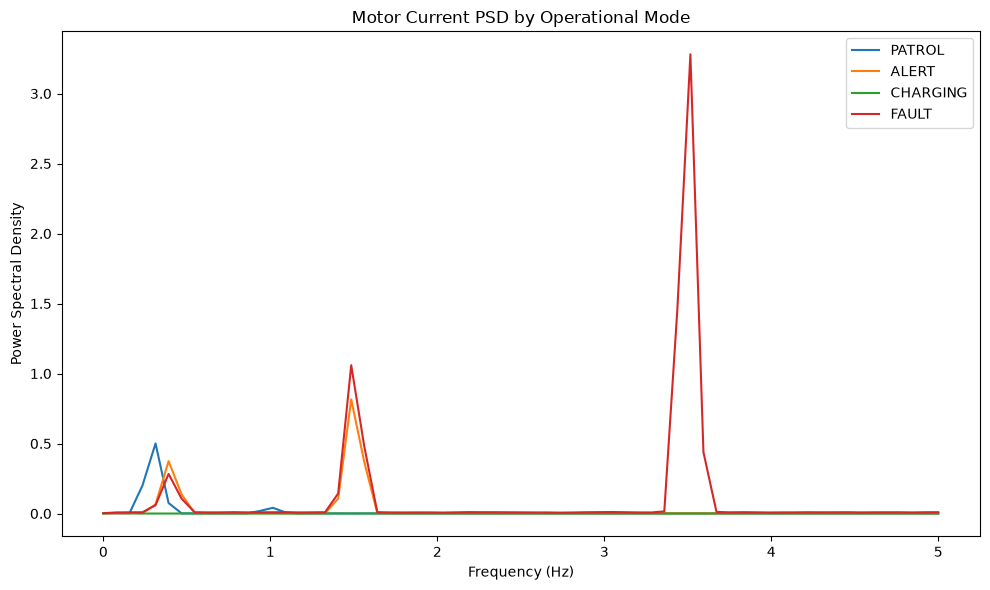

In [53]:
plt.figure(figsize=(10, 6))

for mode in MODES:

    freqs, mean_psd, std_psd = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="motor_current",
        fs=HF_FS,
        nperseg=256
    )

    mask = freqs <= 5

    plt.plot(
        freqs[mask],
        mean_psd[mask],
        label=mode
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Motor Current PSD by Operational Mode")
plt.legend()

plt.tight_layout()
plt.show()

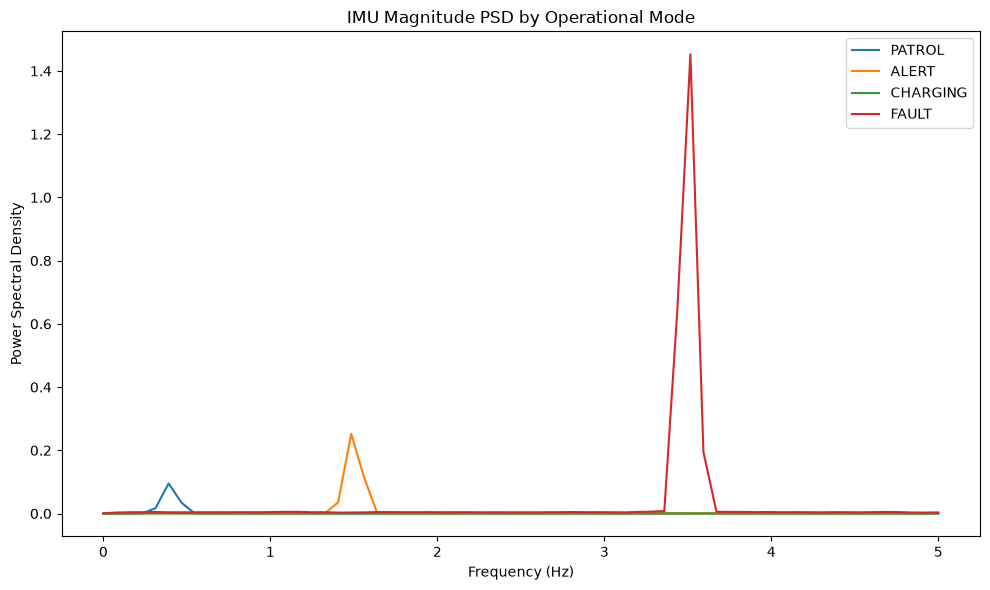

In [54]:
plt.figure(figsize=(10, 6))

for mode in MODES:

    freqs, mean_psd, std_psd = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="imu_magnitude",
        fs=HF_FS,
        nperseg=256
    )

    mask = freqs <= 5

    plt.plot(
        freqs[mask],
        mean_psd[mask],
        label=mode
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("IMU Magnitude PSD by Operational Mode")
plt.legend()

plt.tight_layout()
plt.show()

## Band Energy Extraction

In [55]:
frequency_bands = {
    "Low": (0.0, 0.5),
    "Medium": (0.5, 2.0),
    "High": (2.0, 5.0)
}

In [56]:
def band_energy(freqs, psd, low, high):
    """
    Integrate PSD within a specified frequency band.
    """

    mask = (freqs >= low) & (freqs <= high)

    return np.trapezoid(
        psd[mask],
        freqs[mask]
    )

In [57]:
motor_band_results = {}

for mode in MODES:

    freqs, mean_psd, _ = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="motor_current",
        fs=HF_FS,
        nperseg=256
    )

    energies = {}

    for band_name, (low, high) in frequency_bands.items():

        energies[band_name] = band_energy(
            freqs,
            mean_psd,
            low,
            high
        )

    motor_band_results[mode] = energies

motor_band_df = pd.DataFrame(
    motor_band_results
).T

motor_band_df.round(4)

,Low,Medium,High
PATROL,0.0610,0.0063,0.0030
ALERT,0.0403,0.1038,0.0066
CHARGING,0.0006,0.0001,0.0003
FAULT,0.0331,0.1418,0.4292


In [58]:
motor_relative_band_df = motor_band_df.div(
    motor_band_df.sum(axis=1),
    axis=0
)

motor_relative_band_df.round(3)

,Low,Medium,High
PATROL,0.868,0.090,0.043
ALERT,0.267,0.689,0.044
CHARGING,0.584,0.134,0.281
FAULT,0.055,0.235,0.711


In [59]:
motor_relative_band_df.sum(axis=1)

PATROL      1.0
ALERT       1.0
CHARGING    1.0
FAULT       1.0
dtype: float64

### IMU Band Energy

In [60]:
imu_band_results = {}

for mode in MODES:

    freqs, mean_psd, _ = average_window_psd(
        hf_df=hf_df,
        mode=mode,
        signal_col="imu_magnitude",
        fs=HF_FS,
        nperseg=256
    )

    energies = {}

    for band_name, (low, high) in frequency_bands.items():

        energies[band_name] = band_energy(
            freqs,
            mean_psd,
            low,
            high
        )

    imu_band_results[mode] = energies

imu_band_df = pd.DataFrame(
    imu_band_results
).T

imu_relative_band_df = imu_band_df.div(
    imu_band_df.sum(axis=1),
    axis=0
)

imu_band_df.round(4)

,Low,Medium,High
PATROL,0.0102,0.0005,0.0011
ALERT,0.0005,0.0325,0.0030
CHARGING,0.0000,0.0001,0.0001
FAULT,0.0018,0.0060,0.1912


In [61]:
imu_relative_band_df.round(3)

,Low,Medium,High
PATROL,0.866,0.043,0.091
ALERT,0.013,0.903,0.084
CHARGING,0.089,0.289,0.622
FAULT,0.009,0.030,0.961


### Motor Current Relative Band Energy Heatmap

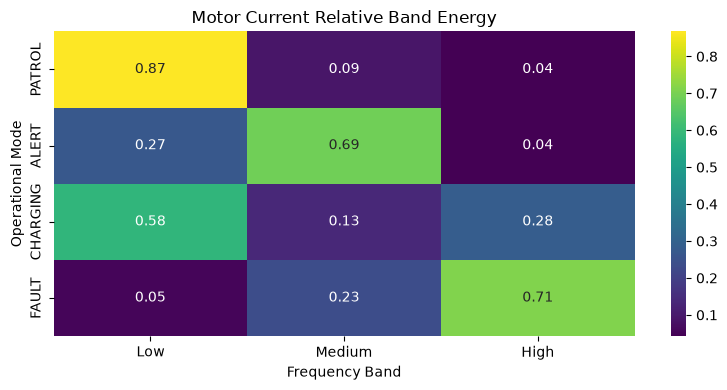

In [62]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    motor_relative_band_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("Motor Current Relative Band Energy")

plt.tight_layout()
plt.show()

### IMU Relative Band Energy Heatmap

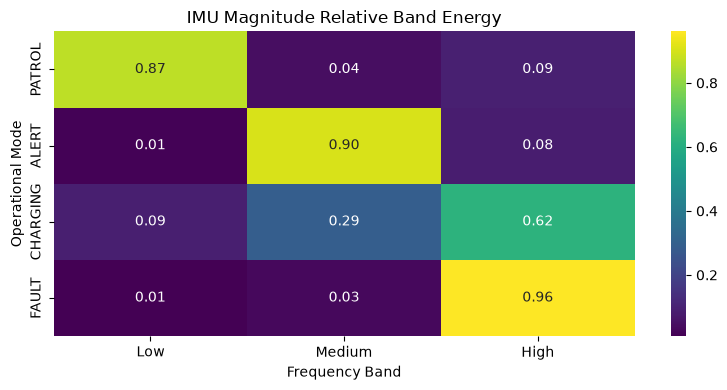

In [63]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    imu_relative_band_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("IMU Magnitude Relative Band Energy")

plt.tight_layout()
plt.show()

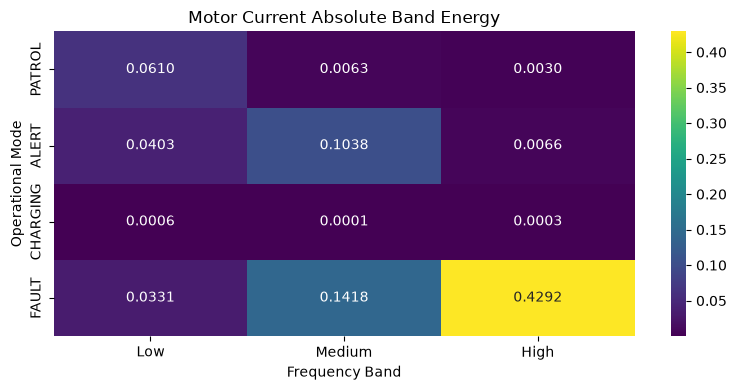

In [64]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    motor_band_df,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("Motor Current Absolute Band Energy")

plt.tight_layout()
plt.show()

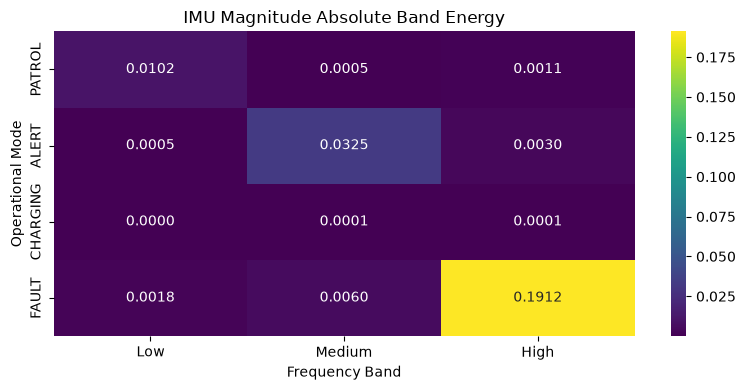

In [65]:
plt.figure(figsize=(8, 4))

sns.heatmap(
    imu_band_df,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.xlabel("Frequency Band")
plt.ylabel("Operational Mode")
plt.title("IMU Magnitude Absolute Band Energy")

plt.tight_layout()
plt.show()